In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
import mne_bids
from mne_bids import BIDSPath

from scipy import stats

In [2]:
# -----------------------------
# Dataset information
# -----------------------------
bids_dir = Path(r"E:\IEEG-FMRI Dataset")

preprocess_dir = Path(r"E:\IEEG-FMRI-DATASET-ANALYSIS\preprocess")

subjects = mne_bids.get_entity_vals(bids_dir, "subject")

session = "iemu"
datatype = "ieeg"
acquisition = "clinical"

In [3]:
# Load the preprocessed recordings

preprocessed_film = {}

for subject in subjects:

    fif_file = preprocess_dir / f"sub-{subject}_film_preprocessed_raw.fif"

    if not fif_file.exists():
        print(f"Skipping subject {subject}: preprocessed file not found")
        continue

    raw = mne.io.read_raw_fif(
        fif_file,
        preload=True,
        verbose=False
    )

    preprocessed_film[subject] = raw

    print(
        f"Loaded subject {subject} | "
        f"{len(raw.ch_names)} channels | "
        f"{raw.info['sfreq']} Hz"
    )

Loaded subject 01 | 101 channels | 2048.0 Hz
Loaded subject 02 | 59 channels | 512.0 Hz
Loaded subject 03 | 101 channels | 512.0 Hz
Skipping subject 04: preprocessed file not found
Loaded subject 05 | 73 channels | 2048.0 Hz
Loaded subject 06 | 102 channels | 512.0 Hz
Loaded subject 07 | 55 channels | 512.0 Hz
Skipping subject 08: preprocessed file not found
Loaded subject 09 | 69 channels | 2048.0 Hz
Loaded subject 10 | 90 channels | 512.0 Hz
Skipping subject 11: preprocessed file not found
Loaded subject 12 | 64 channels | 2048.0 Hz
Loaded subject 13 | 94 channels | 512.0 Hz
Loaded subject 14 | 109 channels | 512.0 Hz
Skipping subject 15: preprocessed file not found
Loaded subject 16 | 103 channels | 512.0 Hz
Loaded subject 17 | 89 channels | 512.0 Hz
Loaded subject 18 | 61 channels | 512.0 Hz
Loaded subject 19 | 78 channels | 512.0 Hz
Loaded subject 20 | 88 channels | 512.0 Hz
Loaded subject 21 | 109 channels | 2048.0 Hz
Loaded subject 22 | 51 channels | 512.0 Hz
Loaded subject 23 |

In [4]:
raw.get_data()

array([[ 5.24932875e-05,  4.51858068e-05,  3.77208416e-05, ...,
        -1.49180996e-04, -1.51106229e-04, -1.50950626e-04],
       [-6.16668694e-05, -6.19478378e-05, -5.84167501e-05, ...,
        -1.92268097e-04, -1.97179455e-04, -2.00267023e-04],
       [-6.12762451e-05, -6.03121443e-05, -5.46250412e-05, ...,
        -1.35674723e-04, -1.33761656e-04, -1.33665468e-04],
       ...,
       [-1.79168710e-05, -2.64266928e-05, -3.49760594e-05, ...,
         1.33928415e-05,  1.09163857e-05,  8.71734665e-06],
       [ 9.24346896e-05,  8.94649202e-05,  8.56883853e-05, ...,
         2.03321906e-05,  1.98145590e-05,  1.81900032e-05],
       [ 1.01712038e-04,  1.14087459e-04,  1.13247886e-04, ...,
        -4.95102722e-04, -4.91301005e-04, -4.83958429e-04]])

In [5]:
#Read events.tsv

from pathlib import Path

film_events = {}

for subject in preprocessed_film.keys():


    ieeg_dir = bids_dir / f"sub-{subject}" / f"ses-{session}" / datatype

#     events_path = mne_bids.BIDSPath(
#     subject=subject,
#     session=session,
#     datatype=datatype,
#     task="film",
#     run="1",      
#     suffix="events",
#     extension=".tsv",
#     root=bids_dir,
#     )

# we can't use the above method to specify path since run can be 1 or 2. so we're using glob...which searches the folder for files whose name matches the pattern
  
    film_events = {}

    for subject in preprocessed_film.keys():

        ieeg_dir = bids_dir / f"sub-{subject}" / f"ses-{session}" / datatype

        # Find all film event files
        event_files = sorted(ieeg_dir.glob("*task-film*_events.tsv"))

        if len(event_files) == 0:
            print(f"No event file found for subject {subject}")
            continue

        # Always use the first (clinical) run
        events = pd.read_csv(event_files[0], sep="\t")

        film_events[subject] = events

    print(f"Subject {subject}")
    print(events.head())
    print("-" * 50)

Subject 63
     onset  duration  trial_type  value
0   45.201     0.018  start task      9
1   45.219    29.996       music      2
2   75.215    30.002      speech      1
3  105.217    30.002       music      2
4  135.219    30.004      speech      1
--------------------------------------------------
Subject 63
     onset  duration  trial_type  value
0   45.201     0.018  start task      9
1   45.219    29.996       music      2
2   75.215    30.002      speech      1
3  105.217    30.002       music      2
4  135.219    30.004      speech      1
--------------------------------------------------
Subject 63
     onset  duration  trial_type  value
0   45.201     0.018  start task      9
1   45.219    29.996       music      2
2   75.215    30.002      speech      1
3  105.217    30.002       music      2
4  135.219    30.004      speech      1
--------------------------------------------------
Subject 63
     onset  duration  trial_type  value
0   45.201     0.018  start task      9
1  

In [6]:
import numpy as np

mne_events = {}

for subject in preprocessed_film.keys():

    raw = preprocessed_film[subject]
    events = film_events[subject]

    # Keep only speech and music events
    events = events[events["trial_type"].isin(["speech", "music"])]

    # Convert onset (seconds) to sample numbers
    samples = (events["onset"] * raw.info["sfreq"]).astype(int)

    # Event IDs
    event_ids = events["value"].astype(int)

    # MNE expects: [sample, previous_value, event_id]
    event_array = np.column_stack([
        samples,
        np.zeros(len(samples), dtype=int),
        event_ids
    ])

    mne_events[subject] = event_array

    print(f"\nSubject {subject}")
    print(event_array[:5])


Subject 01
[[ 43673      0      2]
 [105113      0      1]
 [166553      0      2]
 [227993      0      1]
 [289433      0      2]]

Subject 02
[[20255     0     2]
 [35615     0     1]
 [50975     0     2]
 [66335     0     1]
 [81695     0     2]]

Subject 03
[[  474     0     2]
 [15830     0     1]
 [31190     0     2]
 [46550     0     1]
 [61910     0     2]]

Subject 05
[[236433      0      2]
 [297869      0      1]
 [359309      0      2]
 [420749      0      1]
 [482191      0      2]]

Subject 06
[[ 2716     0     2]
 [18067     0     1]
 [33428     0     2]
 [48791     0     1]
 [64152     0     2]]

Subject 07
[[ 6240     0     2]
 [21600     0     1]
 [36960     0     2]
 [52320     0     1]
 [67680     0     2]]

Subject 09
[[ 26261      0      2]
 [ 87701      0      1]
 [149153      0      2]
 [210604      0      1]
 [272056      0      2]]

Subject 10
[[  373     0     2]
 [15730     0     1]
 [31090     0     2]
 [46450     0     1]
 [61810     0     2]]

Subject 12

In [7]:
#Create epochs for speech and music

speech_music_epochs = {}

event_id = {
    "speech": 1,
    "music": 2
}

for subject in sorted(preprocessed_film.keys()):

    if subject not in mne_events:
        continue

    raw = preprocessed_film[subject]
    events = mne_events[subject]

    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=0,
        tmax=30,
        baseline=None,
        preload=True,
        verbose=False
    )

    speech_music_epochs[subject] = epochs

    print(
        f"Subject {subject}: "
        f"{len(epochs['speech'])} speech epochs, "
        f"{len(epochs['music'])} music epochs"
    )

Subject 01: 6 speech epochs, 7 music epochs
Subject 02: 6 speech epochs, 7 music epochs
Subject 03: 6 speech epochs, 7 music epochs
Subject 05: 6 speech epochs, 7 music epochs
Subject 06: 6 speech epochs, 7 music epochs
Subject 07: 6 speech epochs, 7 music epochs
Subject 09: 6 speech epochs, 7 music epochs
Subject 10: 6 speech epochs, 7 music epochs
Subject 12: 6 speech epochs, 7 music epochs
Subject 13: 6 speech epochs, 7 music epochs
Subject 14: 6 speech epochs, 7 music epochs
Subject 16: 6 speech epochs, 7 music epochs
Subject 17: 6 speech epochs, 7 music epochs
Subject 18: 6 speech epochs, 7 music epochs
Subject 19: 6 speech epochs, 7 music epochs
Subject 20: 6 speech epochs, 7 music epochs
Subject 21: 6 speech epochs, 7 music epochs
Subject 22: 6 speech epochs, 7 music epochs
Subject 23: 6 speech epochs, 7 music epochs
Subject 24: 6 speech epochs, 7 music epochs
Subject 25: 6 speech epochs, 7 music epochs
Subject 26: 6 speech epochs, 7 music epochs
Subject 27: 6 speech epochs, 7 m

In [8]:
for subject in list(preprocessed_film.keys())[:5]:
    print(subject, preprocessed_film[subject].info["sfreq"])

01 2048.0
02 512.0
03 512.0
05 2048.0
06 512.0


In [9]:
epochs = speech_music_epochs["01"]

print(epochs)

<Epochs | 13 events (all good), 0 – 30 s (baseline off), ~615.6 MiB, data loaded,
 'speech': 6
 'music': 7>


In [10]:
#Compute PSD for each subject

from mne.time_frequency import psd_array_welch

subject_psd = {}

for subject in sorted(speech_music_epochs.keys()):

    epochs = speech_music_epochs[subject]

    subject_psd[subject] = {}

    for condition in ["speech", "music"]:

        # Shape: (n_epochs, n_channels, n_times)
        data = epochs[condition].get_data()

        sfreq = epochs.info["sfreq"]

        print("Subject:", subject)
        print("Sampling rate:", epochs.info["sfreq"])   # or raw.info["sfreq"]

        psds, freqs = psd_array_welch(
            data,
            sfreq=sfreq,
            fmin=1,
            fmax=120,
            n_fft=2048,
            average="mean",
            verbose=False
        )

        print("Frequency shape:", freqs.shape)
        print("First 10 frequencies:", freqs[:10])
        print("Last 10 frequencies:", freqs[-10:])

        subject_psd[subject][condition] = {
            "psd": psds,
            "freqs": freqs
        }

    print(f"Computed PSD for subject {subject}")

Subject: 01
Sampling rate: 2048.0
Frequency shape: (120,)
First 10 frequencies: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Last 10 frequencies: [111. 112. 113. 114. 115. 116. 117. 118. 119. 120.]
Subject: 01
Sampling rate: 2048.0
Frequency shape: (120,)
First 10 frequencies: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Last 10 frequencies: [111. 112. 113. 114. 115. 116. 117. 118. 119. 120.]
Computed PSD for subject 01
Subject: 02
Sampling rate: 512.0
Frequency shape: (477,)
First 10 frequencies: [1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25]
Last 10 frequencies: [117.75 118.   118.25 118.5  118.75 119.   119.25 119.5  119.75 120.  ]
Subject: 02
Sampling rate: 512.0
Frequency shape: (477,)
First 10 frequencies: [1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25]
Last 10 frequencies: [117.75 118.   118.25 118.5  118.75 119.   119.25 119.5  119.75 120.  ]
Computed PSD for subject 02
Subject: 03
Sampling rate: 512.0
Frequency shape: (477,)
First 10 frequencies: [1.   1.25 1.5  1.75 2.   2

In [11]:
psd = subject_psd["01"]["speech"]["psd"]

print(psd.shape)

(6, 101, 120)


In [12]:
#Average PSD within each subject

subject_psd_mean = {}

for subject in sorted(subject_psd.keys()):

    subject_psd_mean[subject] = {}

    for condition in ["speech", "music"]:

        psd = subject_psd[subject][condition]["psd"]
        freqs = subject_psd[subject][condition]["freqs"]

        # Average across epochs
        psd_mean_epochs = psd.mean(axis=0)      # (n_channels, n_freqs)

        # Average across channels
        psd_mean_subject = psd_mean_epochs.mean(axis=0)   # (n_freqs,)

        subject_psd_mean[subject][condition] = {
            "psd": psd_mean_subject,
            "freqs": freqs
        }

    print(f"Subject {subject} completed")

Subject 01 completed
Subject 02 completed
Subject 03 completed
Subject 05 completed
Subject 06 completed
Subject 07 completed
Subject 09 completed
Subject 10 completed
Subject 12 completed
Subject 13 completed
Subject 14 completed
Subject 16 completed
Subject 17 completed
Subject 18 completed
Subject 19 completed
Subject 20 completed
Subject 21 completed
Subject 22 completed
Subject 23 completed
Subject 24 completed
Subject 25 completed
Subject 26 completed
Subject 27 completed
Subject 28 completed
Subject 30 completed
Subject 31 completed
Subject 32 completed
Subject 33 completed
Subject 34 completed
Subject 36 completed
Subject 37 completed
Subject 38 completed
Subject 39 completed
Subject 40 completed
Subject 41 completed
Subject 42 completed
Subject 43 completed
Subject 45 completed
Subject 46 completed
Subject 48 completed
Subject 49 completed
Subject 50 completed
Subject 51 completed
Subject 54 completed
Subject 55 completed
Subject 57 completed
Subject 58 completed
Subject 59 co

In [13]:
print(subject_psd_mean["01"]["speech"]["psd"].shape)

(120,)


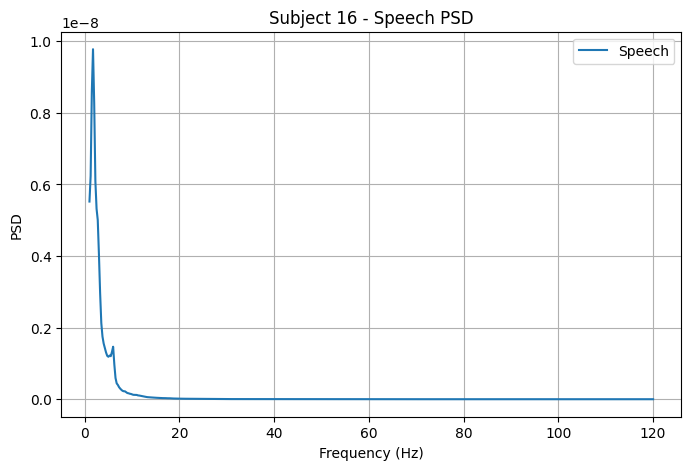

In [17]:
#plot one subject

import matplotlib.pyplot as plt

subject = "16"

freqs = subject_psd_mean[subject]["speech"]["freqs"]
psd = subject_psd_mean[subject]["speech"]["psd"]

plt.figure(figsize=(8,5))
plt.plot(freqs, psd, label="Speech")

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title(f"Subject {subject} - Speech PSD")
plt.legend()
plt.grid(True)

plt.show()

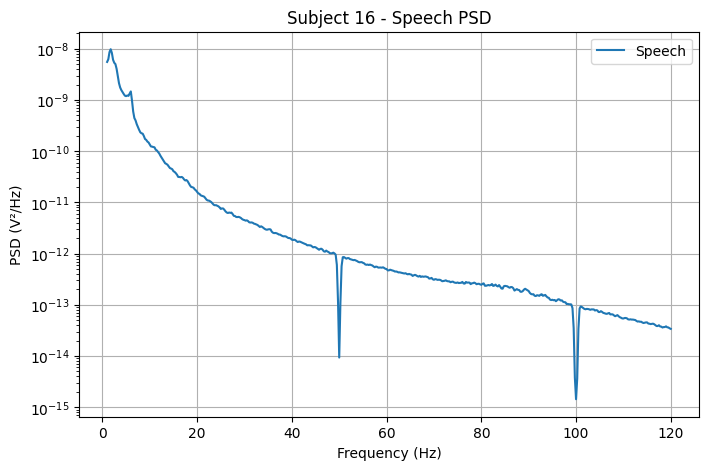

In [18]:
#In neuroscience, PSDs are almost always plotted on a logarithmic scale, because the power spans several orders of magnitude and the low-frequency components otherwise dominate the figure.

#plt.semilogy(...)
# semilogy() means:
# x-axis remains linear
# y-axis becomes logarithmic
import matplotlib.pyplot as plt

subject = "16"

freqs = subject_psd_mean[subject]["speech"]["freqs"]
psd = subject_psd_mean[subject]["speech"]["psd"]

plt.figure(figsize=(8, 5))
plt.semilogy(freqs, psd, label="Speech")

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (V²/Hz)")
plt.title(f"Subject {subject} - Speech PSD")
plt.grid(True)
plt.legend()

plt.show()

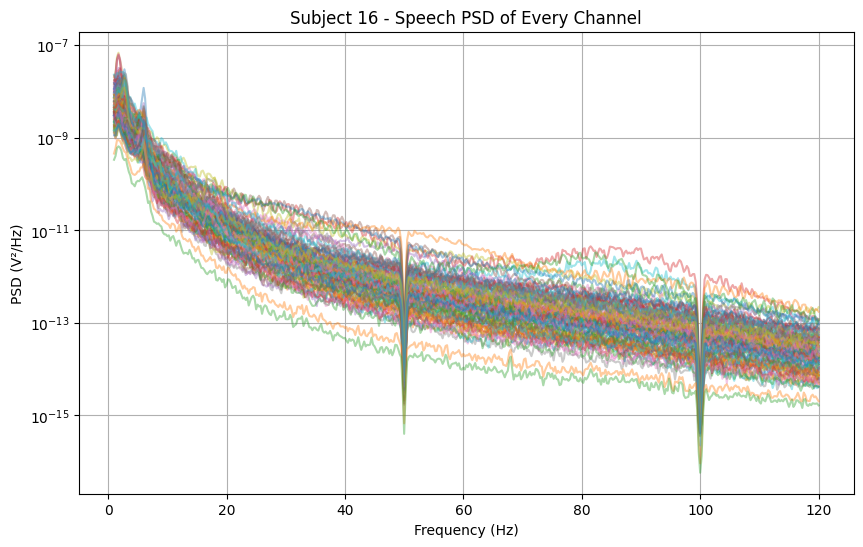

In [16]:
import matplotlib.pyplot as plt

subject = "16"

psd = subject_psd[subject]["speech"]["psd"]      # (epochs, channels, freqs)
freqs = subject_psd[subject]["speech"]["freqs"]

# Average across epochs only
channel_psd = psd.mean(axis=0)                   # (channels, freqs)

plt.figure(figsize=(10,6))

for ch in range(channel_psd.shape[0]):
    plt.semilogy(freqs, channel_psd[ch], alpha=0.4)

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (V²/Hz)")
plt.title(f"Subject {subject} - Speech PSD of Every Channel")
plt.grid(True)

plt.show()

In [17]:
from pathlib import Path

for f in sorted(preprocess_dir.glob("*.fif")):
    print(f.name)

sub-01_film_preprocessed_raw.fif
sub-01_rest_preprocessed_raw.fif
sub-02_film_preprocessed_raw.fif
sub-02_rest_preprocessed_raw.fif
sub-03_film_preprocessed_raw.fif
sub-03_rest_preprocessed_raw.fif
sub-05_film_preprocessed_raw.fif
sub-05_rest_preprocessed_raw.fif
sub-06_film_preprocessed_raw.fif
sub-06_rest_preprocessed_raw.fif
sub-07_film_preprocessed_raw.fif
sub-07_rest_preprocessed_raw.fif
sub-09_film_preprocessed_raw.fif
sub-09_rest_preprocessed_raw.fif
sub-10_film_preprocessed_raw.fif
sub-10_rest_preprocessed_raw.fif
sub-12_film_preprocessed_raw.fif
sub-12_rest_preprocessed_raw.fif
sub-13_film_preprocessed_raw.fif
sub-13_rest_preprocessed_raw.fif
sub-14_film_preprocessed_raw.fif
sub-14_rest_preprocessed_raw.fif
sub-16_film_preprocessed_raw.fif
sub-16_rest_preprocessed_raw.fif
sub-17_film_preprocessed_raw.fif
sub-17_rest_preprocessed_raw.fif
sub-18_film_preprocessed_raw.fif
sub-18_rest_preprocessed_raw.fif
sub-19_film_preprocessed_raw.fif
sub-19_rest_preprocessed_raw.fif
sub-20_fil

In [18]:
rest_files = sorted(preprocess_dir.glob("*rest*.fif"))

print(f"Number of rest files: {len(rest_files)}")

for f in rest_files:
    print(f.name)

Number of rest files: 50
sub-01_rest_preprocessed_raw.fif
sub-02_rest_preprocessed_raw.fif
sub-03_rest_preprocessed_raw.fif
sub-05_rest_preprocessed_raw.fif
sub-06_rest_preprocessed_raw.fif
sub-07_rest_preprocessed_raw.fif
sub-09_rest_preprocessed_raw.fif
sub-10_rest_preprocessed_raw.fif
sub-12_rest_preprocessed_raw.fif
sub-13_rest_preprocessed_raw.fif
sub-14_rest_preprocessed_raw.fif
sub-16_rest_preprocessed_raw.fif
sub-17_rest_preprocessed_raw.fif
sub-18_rest_preprocessed_raw.fif
sub-19_rest_preprocessed_raw.fif
sub-20_rest_preprocessed_raw.fif
sub-21_rest_preprocessed_raw.fif
sub-22_rest_preprocessed_raw.fif
sub-23_rest_preprocessed_raw.fif
sub-24_rest_preprocessed_raw.fif
sub-25_rest_preprocessed_raw.fif
sub-26_rest_preprocessed_raw.fif
sub-27_rest_preprocessed_raw.fif
sub-28_rest_preprocessed_raw.fif
sub-30_rest_preprocessed_raw.fif
sub-31_rest_preprocessed_raw.fif
sub-32_rest_preprocessed_raw.fif
sub-34_rest_preprocessed_raw.fif
sub-36_rest_preprocessed_raw.fif
sub-37_rest_prepro

In [19]:
from pathlib import Path

for subject in ["01", "02", "03"]:

    ieeg_dir = bids_dir / f"sub-{subject}" / f"ses-{session}" / datatype

    print(f"\nSubject {subject}")

    for f in sorted(ieeg_dir.glob("*rest*")):
        print(f.name)


Subject 01
sub-01_ses-iemu_task-rest_acq-clinical_run-1_channels.tsv
sub-01_ses-iemu_task-rest_acq-clinical_run-1_ieeg.eeg
sub-01_ses-iemu_task-rest_acq-clinical_run-1_ieeg.json
sub-01_ses-iemu_task-rest_acq-clinical_run-1_ieeg.vhdr
sub-01_ses-iemu_task-rest_acq-clinical_run-1_ieeg.vmrk
sub-01_ses-iemu_task-rest_run-1_events.tsv

Subject 02
sub-02_ses-iemu_task-rest_acq-clinical_run-1_channels.tsv
sub-02_ses-iemu_task-rest_acq-clinical_run-1_ieeg.eeg
sub-02_ses-iemu_task-rest_acq-clinical_run-1_ieeg.json
sub-02_ses-iemu_task-rest_acq-clinical_run-1_ieeg.vhdr
sub-02_ses-iemu_task-rest_acq-clinical_run-1_ieeg.vmrk
sub-02_ses-iemu_task-rest_run-1_events.tsv

Subject 03
sub-03_ses-iemu_task-rest_acq-clinical_run-4_channels.tsv
sub-03_ses-iemu_task-rest_acq-clinical_run-4_ieeg.eeg
sub-03_ses-iemu_task-rest_acq-clinical_run-4_ieeg.json
sub-03_ses-iemu_task-rest_acq-clinical_run-4_ieeg.vhdr
sub-03_ses-iemu_task-rest_acq-clinical_run-4_ieeg.vmrk
sub-03_ses-iemu_task-rest_run-4_events.tsv


In [20]:
#Load all the preprocessed rest FIF files

preprocessed_rest = {}

for subject in subjects:

    fif_file = preprocess_dir / f"sub-{subject}_rest_preprocessed_raw.fif"

    if not fif_file.exists():
        continue

    raw = mne.io.read_raw_fif(
        fif_file,
        preload=True,
        verbose=False
    )

    preprocessed_rest[subject] = raw

print(f"Loaded rest recordings for {len(preprocessed_rest)} subjects.")

Loaded rest recordings for 50 subjects.


In [21]:
print(len(preprocessed_rest))

50


In [22]:
# Create Rest Epochs

rest_epochs = {}

for subject in sorted(preprocessed_rest.keys()):

    raw = preprocessed_rest[subject]

    epochs = []

    # Create six non-overlapping 30-second epochs
    for start in range(0, 180, 30):

        epoch = raw.copy().crop(
            tmin=start,
            tmax=start + 30,
            include_tmax=False
        )

        epochs.append(epoch)

    rest_epochs[subject] = epochs

    print(f"Subject {subject}: {len(epochs)} rest epochs")

Subject 01: 6 rest epochs
Subject 02: 6 rest epochs
Subject 03: 6 rest epochs
Subject 05: 6 rest epochs
Subject 06: 6 rest epochs
Subject 07: 6 rest epochs
Subject 09: 6 rest epochs
Subject 10: 6 rest epochs
Subject 12: 6 rest epochs
Subject 13: 6 rest epochs
Subject 14: 6 rest epochs
Subject 16: 6 rest epochs
Subject 17: 6 rest epochs
Subject 18: 6 rest epochs
Subject 19: 6 rest epochs
Subject 20: 6 rest epochs
Subject 21: 6 rest epochs
Subject 22: 6 rest epochs
Subject 23: 6 rest epochs
Subject 24: 6 rest epochs
Subject 25: 6 rest epochs
Subject 26: 6 rest epochs
Subject 27: 6 rest epochs
Subject 28: 6 rest epochs
Subject 30: 6 rest epochs
Subject 31: 6 rest epochs
Subject 32: 6 rest epochs
Subject 34: 6 rest epochs
Subject 36: 6 rest epochs
Subject 37: 6 rest epochs
Subject 38: 6 rest epochs
Subject 39: 6 rest epochs
Subject 40: 6 rest epochs
Subject 41: 6 rest epochs
Subject 42: 6 rest epochs
Subject 43: 6 rest epochs
Subject 45: 6 rest epochs
Subject 46: 6 rest epochs
Subject 48: 

In [23]:
print(len(rest_epochs["01"]))

6


In [24]:
print(rest_epochs["01"][0])

<Raw | sub-01_rest_preprocessed_raw.fif, 102 x 61440 (30.0 s), ~47.9 MiB, data loaded>


In [25]:
#Compute Rest PSD

from mne.time_frequency import psd_array_welch

for subject in sorted(rest_epochs.keys()):

    # Convert the 6 Raw segments into one NumPy array
    data = np.stack(
        [epoch.get_data() for epoch in rest_epochs[subject]],
        axis=0
    )

    sfreq = preprocessed_rest[subject].info["sfreq"]

    psds, freqs = psd_array_welch(
        data,
        sfreq=sfreq,
        fmin=1,
        fmax=120,
        n_fft=2048,
        average="mean",
        verbose=False
    )

    subject_psd[subject]["rest"] = {
        "psd": psds,
        "freqs": freqs
    }

    print(f"Computed rest PSD for subject {subject}")

Computed rest PSD for subject 01
Computed rest PSD for subject 02
Computed rest PSD for subject 03
Computed rest PSD for subject 05
Computed rest PSD for subject 06
Computed rest PSD for subject 07
Computed rest PSD for subject 09
Computed rest PSD for subject 10
Computed rest PSD for subject 12
Computed rest PSD for subject 13
Computed rest PSD for subject 14
Computed rest PSD for subject 16
Computed rest PSD for subject 17
Computed rest PSD for subject 18
Computed rest PSD for subject 19
Computed rest PSD for subject 20
Computed rest PSD for subject 21
Computed rest PSD for subject 22
Computed rest PSD for subject 23
Computed rest PSD for subject 24
Computed rest PSD for subject 25
Computed rest PSD for subject 26
Computed rest PSD for subject 27
Computed rest PSD for subject 28
Computed rest PSD for subject 30
Computed rest PSD for subject 31
Computed rest PSD for subject 32
Computed rest PSD for subject 34
Computed rest PSD for subject 36
Computed rest PSD for subject 37
Computed r

In [26]:
for subject in sorted(subject_psd.keys()):

    if "rest" not in subject_psd[subject]:
        print(f"Missing rest PSD for subject {subject}")

Missing rest PSD for subject 33


In [27]:
print("Subjects with film PSD :", len(subject_psd))
print("Subjects with rest FIF :", len(preprocessed_rest))
print("Subjects with rest epochs :", len(rest_epochs))

Subjects with film PSD : 51
Subjects with rest FIF : 50
Subjects with rest epochs : 50


<!-- Raw recordings
      ↓
Preprocessing                    ✅
      ↓
Speech/Music epochs              ✅
      ↓
Rest epochs                      ✅
      ↓
Welch PSD                        ✅
      ↓
Average across epochs            ✅
      ↓
Average across channels          ✅
      ↓
One PSD curve per subject        ✅ -->

In [28]:
subject_psd_mean = {}

for subject in sorted(subject_psd.keys()):

    # Skip subjects missing any condition
    if not all(cond in subject_psd[subject]
               for cond in ["speech", "music", "rest"]):
        print(f"Skipping subject {subject}: missing one or more conditions")
        continue

    subject_psd_mean[subject] = {}

    for condition in ["speech", "music", "rest"]:

        psd = subject_psd[subject][condition]["psd"]
        freqs = subject_psd[subject][condition]["freqs"]

        # Average across epochs
        psd_mean_epochs = psd.mean(axis=0)

        # Average across channels
        psd_mean_subject = psd_mean_epochs.mean(axis=0)

        subject_psd_mean[subject][condition] = {
            "psd": psd_mean_subject,
            "freqs": freqs
        }

print(f"\nFinished averaging PSDs for {len(subject_psd_mean)} subjects.")

Skipping subject 33: missing one or more conditions

Finished averaging PSDs for 50 subjects.


In [29]:
# Stack all subjects' PSDs

import numpy as np

speech_psd = []
music_psd = []
rest_psd = []

for subject in sorted(subject_psd_mean.keys()):

    speech_psd.append(subject_psd_mean[subject]["speech"]["psd"])
    music_psd.append(subject_psd_mean[subject]["music"]["psd"])
    rest_psd.append(subject_psd_mean[subject]["rest"]["psd"])

speech_psd = np.stack(speech_psd)
music_psd = np.stack(music_psd)
rest_psd = np.stack(rest_psd)

freqs = subject_psd_mean[next(iter(subject_psd_mean))]["speech"]["freqs"]

print("Speech PSD shape:", speech_psd.shape)
print("Music PSD shape:", music_psd.shape)
print("Rest PSD shape:", rest_psd.shape)

ValueError: all input arrays must have the same shape

In [30]:
for subject in sorted(subject_psd_mean.keys()):
    shape = subject_psd_mean[subject]["speech"]["psd"].shape
    print(subject, shape)

01 (120,)
02 (477,)
03 (477,)
05 (120,)
06 (477,)
07 (477,)
09 (120,)
10 (477,)
12 (120,)
13 (477,)
14 (477,)
16 (477,)
17 (477,)
18 (477,)
19 (477,)
20 (477,)
21 (120,)
22 (477,)
23 (120,)
24 (477,)
25 (120,)
26 (477,)
27 (477,)
28 (477,)
30 (120,)
31 (477,)
32 (120,)
34 (477,)
36 (120,)
37 (477,)
38 (477,)
39 (477,)
40 (477,)
41 (477,)
42 (120,)
43 (477,)
45 (477,)
46 (477,)
48 (477,)
49 (477,)
50 (477,)
51 (120,)
54 (477,)
55 (477,)
57 (477,)
58 (477,)
59 (477,)
60 (477,)
61 (120,)
63 (477,)


In [31]:
print(subject_psd_mean["01"]["speech"]["freqs"][:10])
print(subject_psd_mean["02"]["speech"]["freqs"][:10])

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25]


In [32]:
print(raw.info["sfreq"])
print(freqs.shape)
print(freqs[:10])
print(freqs[-10:])

512.0
(477,)
[1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25]
[117.75 118.   118.25 118.5  118.75 119.   119.25 119.5  119.75 120.  ]


In [33]:
print(raw.info["sfreq"])
print(freqs.shape)
print(freqs[:10])
print(freqs[-10:])

512.0
(477,)
[1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25]
[117.75 118.   118.25 118.5  118.75 119.   119.25 119.5  119.75 120.  ]


In [34]:
print(preprocessed_film["01"].info["sfreq"])
print(preprocessed_film["02"].info["sfreq"])

2048.0
512.0


In [35]:
#"Recordings in the dataset were acquired at different sampling frequencies, 
# resulting in PSDs evaluated on different frequency grids. 
# To enable group-level averaging, each subject's PSD was interpolated onto a 
# common 1 Hz frequency grid (1–120 Hz) before computing the grand average."

<!-- #"Recordings in the dataset were acquired at different sampling frequencies, resulting in PSDs evaluated on different frequency grids. To enable group-level averaging, each subject's PSD was interpolated onto a common 1 Hz frequency grid (1–120 Hz) before computing the grand average." -->

In [36]:
#Interpolate all PSDs to a common 1 Hz frequency grid

import numpy as np

# Common frequency grid (1 Hz spacing)
common_freqs = np.arange(1, 121, 1)

subject_psd_interp = {}

for subject in sorted(subject_psd_mean.keys()):

    subject_psd_interp[subject] = {}

    for condition in ["speech", "music", "rest"]:

        freqs = subject_psd_mean[subject][condition]["freqs"]
        psd = subject_psd_mean[subject][condition]["psd"]

        # Interpolate PSD onto the common frequency grid
        psd_interp = np.interp(common_freqs, freqs, psd)

        subject_psd_interp[subject][condition] = {
            "freqs": common_freqs,
            "psd": psd_interp
        }

print("Interpolation completed.")
print("Common frequency grid shape:", common_freqs.shape)

Interpolation completed.
Common frequency grid shape: (120,)


Subjects ranked by average Rest PSD (20–120 Hz)

Subject  37 : 6.881e-10
Subject  31 : 4.480e-12
Subject  34 : 4.232e-12
Subject  05 : 4.034e-12
Subject  26 : 3.979e-12
Subject  36 : 3.778e-12
Subject  46 : 3.273e-12
Subject  55 : 2.930e-12
Subject  03 : 2.903e-12
Subject  50 : 2.857e-12
Subject  60 : 2.694e-12
Subject  27 : 2.636e-12
Subject  09 : 2.636e-12
Subject  22 : 2.625e-12
Subject  30 : 2.511e-12
Subject  43 : 2.397e-12
Subject  17 : 2.393e-12
Subject  48 : 2.254e-12
Subject  25 : 2.084e-12
Subject  06 : 2.082e-12
Subject  14 : 2.021e-12
Subject  13 : 2.005e-12
Subject  12 : 1.988e-12
Subject  41 : 1.949e-12
Subject  57 : 1.928e-12
Subject  10 : 1.859e-12
Subject  39 : 1.765e-12
Subject  58 : 1.640e-12
Subject  45 : 1.508e-12
Subject  28 : 1.489e-12
Subject  32 : 1.426e-12
Subject  19 : 1.420e-12
Subject  49 : 1.350e-12
Subject  16 : 1.296e-12
Subject  61 : 1.294e-12
Subject  63 : 1.232e-12
Subject  51 : 1.080e-12
Subject  38 : 1.040e-12
Subject  54 : 1.027e-12
Subject  42 : 9

In [39]:
# Stack all subjects' interpolated PSDs

import numpy as np

speech_psd = []
music_psd = []
rest_psd = []

for subject in sorted(subject_psd_interp.keys()):

    speech_psd.append(subject_psd_interp[subject]["speech"]["psd"])
    music_psd.append(subject_psd_interp[subject]["music"]["psd"])
    rest_psd.append(subject_psd_interp[subject]["rest"]["psd"])

speech_psd = np.stack(speech_psd)
music_psd = np.stack(music_psd)
rest_psd = np.stack(rest_psd)

freqs = common_freqs

print("Speech PSD shape:", speech_psd.shape)
print("Music PSD shape:", music_psd.shape)
print("Rest PSD shape:", rest_psd.shape)

Speech PSD shape: (50, 120)
Music PSD shape: (50, 120)
Rest PSD shape: (50, 120)


In [40]:
# Compute group mean and SEM

from scipy.stats import sem
import numpy as np

speech_mean = np.mean(speech_psd, axis=0)
music_mean = np.mean(music_psd, axis=0)
rest_mean = np.mean(rest_psd, axis=0)

speech_sem = sem(speech_psd, axis=0)
music_sem = sem(music_psd, axis=0)
rest_sem = sem(rest_psd, axis=0)

print("Mean shape:", speech_mean.shape)
print("SEM shape:", speech_sem.shape)

Mean shape: (120,)
SEM shape: (120,)


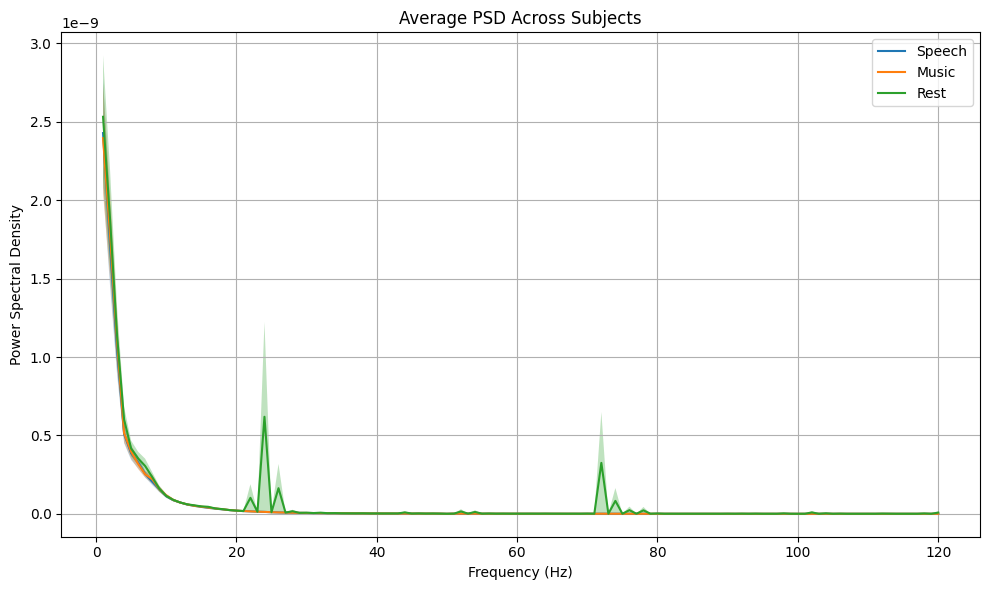

In [48]:
# Plot mean PSD with SEM

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Speech
plt.plot(freqs, speech_mean, label="Speech")
plt.fill_between(
    freqs,
    speech_mean - speech_sem,
    speech_mean + speech_sem,
    alpha=0.3
)

# Music
plt.plot(freqs, music_mean, label="Music")
plt.fill_between(
    freqs,
    music_mean - music_sem,
    music_mean + music_sem,
    alpha=0.3
)

# Rest
plt.plot(freqs, rest_mean, label="Rest")
plt.fill_between(
    freqs,
    rest_mean - rest_sem,
    rest_mean + rest_sem,
    alpha=0.3
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("Average PSD Across Subjects")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()

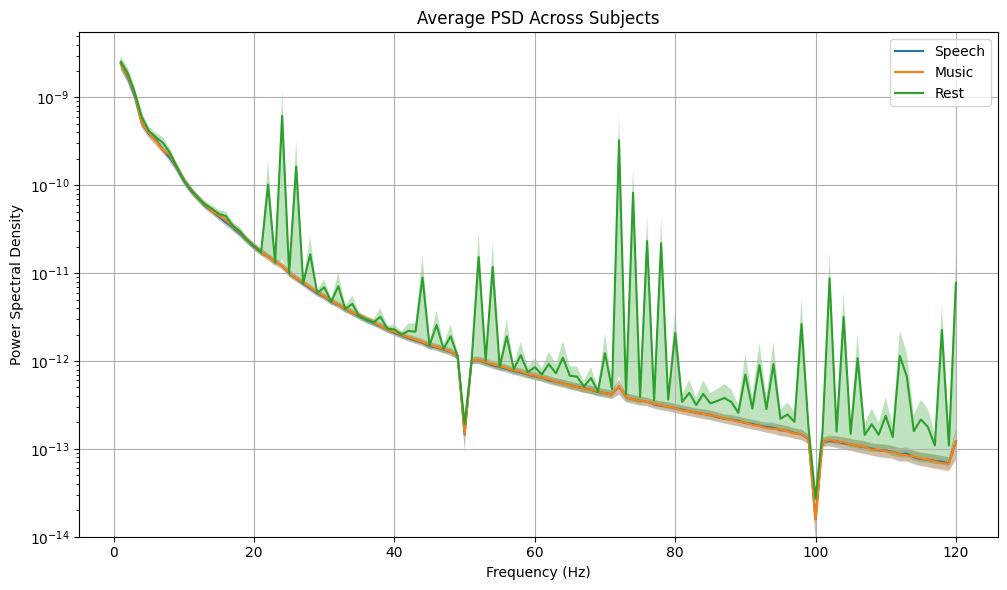

In [ ]:
# Plot mean PSD with SEM

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Speech
plt.plot(freqs, speech_mean, label="Speech")
plt.fill_between(
    freqs,
    speech_mean - speech_sem,
    speech_mean + speech_sem,
    alpha=0.3
)

# Music
plt.plot(freqs, music_mean, label="Music")
plt.fill_between(
    freqs,
    music_mean - music_sem,
    music_mean + music_sem,
    alpha=0.3
)

# Rest
plt.plot(freqs, rest_mean, label="Rest")
plt.fill_between(
    freqs,
    rest_mean - rest_sem,
    rest_mean + rest_sem,
    alpha=0.3
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("Average PSD Across Subjects")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.yscale("log")
plt.ylim(bottom=1e-14)   
plt.show()

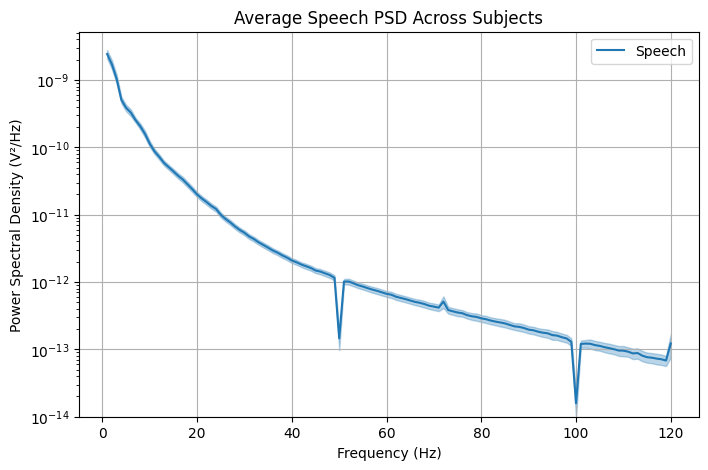

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(freqs, speech_mean, color='tab:blue', label='Speech')
plt.fill_between(
    freqs,
    speech_mean - speech_sem,
    speech_mean + speech_sem,
    color='tab:blue',
    alpha=0.3
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (V²/Hz)")
plt.title("Average Speech PSD Across Subjects")
plt.yscale("log")
plt.ylim(bottom=1e-14)
plt.grid(True)
plt.legend()

plt.show()

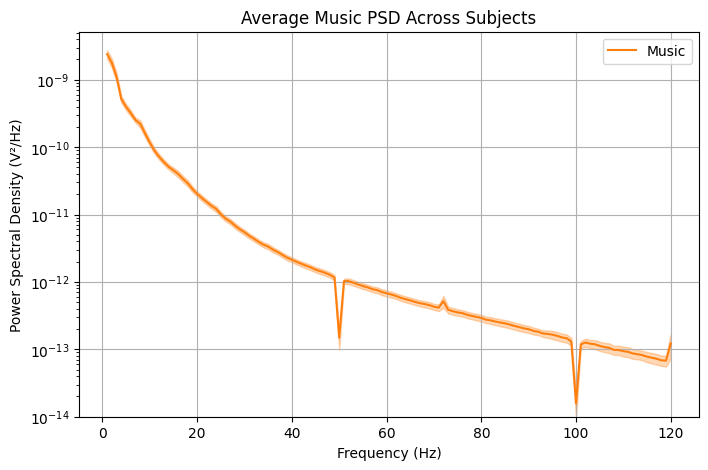

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(freqs, music_mean, color='tab:orange', label='Music')
plt.fill_between(
    freqs,
    music_mean - music_sem,
    music_mean + music_sem,
    color='tab:orange',
    alpha=0.3
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (V²/Hz)")
plt.title("Average Music PSD Across Subjects")
plt.yscale("log")
plt.ylim(bottom=1e-14)
plt.grid(True)
plt.legend()

plt.show()

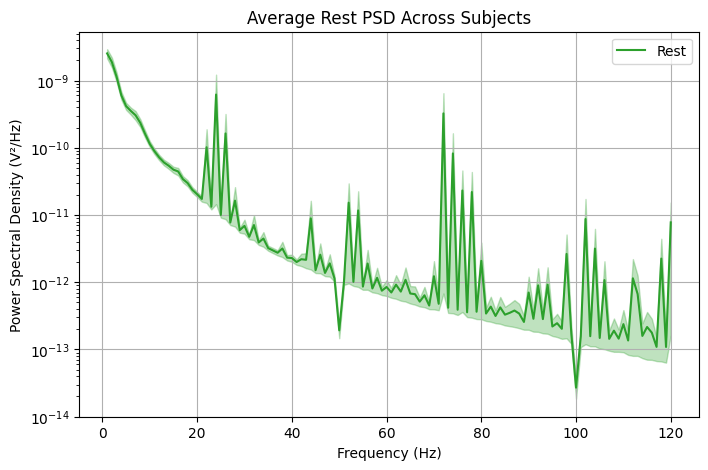

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(freqs, rest_mean, color='tab:green', label='Rest')
plt.fill_between(
    freqs,
    rest_mean - rest_sem,
    rest_mean + rest_sem,
    color='tab:green',
    alpha=0.3
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (V²/Hz)")
plt.title("Average Rest PSD Across Subjects")
plt.yscale("log")
plt.ylim(bottom=1e-14)
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
# Now we will investigate whats happening with one subject in the above plot(use z score to test if its an outlier)

# mask = (common_freqs >= 20) & (common_freqs <= 120)
# It simply says

# Ignore everything below 20 Hz.

# because the suspicious spikes were above 20 Hz.

In [ ]:
#new1
import numpy as np

mask = (common_freqs >= 20) & (common_freqs <= 120)

subjects = []
mean_rest_power = []

for subject in sorted(subject_psd_interp.keys()):

    psd = subject_psd_interp[subject]["rest"]["psd"]

    subjects.append(subject)
    mean_rest_power.append(np.mean(psd[mask]))                  #Instead of keeping 20 to 120 (100) PSD values, we reduce them to ONE number.
                                                                #one psd value per subject
mean_rest_power = np.array(mean_rest_power)

order = np.argsort(mean_rest_power)[::-1]

print("Subjects ranked by average Rest PSD (20–120 Hz)\n")

for i in order:
    print(f"Subject {subjects[i]:>3} : {mean_rest_power[i]:.3e}")

Subjects ranked by average Rest PSD (20–120 Hz)

Subject  37 : 6.881e-10
Subject  31 : 4.480e-12
Subject  34 : 4.232e-12
Subject  05 : 4.034e-12
Subject  26 : 3.979e-12
Subject  36 : 3.778e-12
Subject  46 : 3.273e-12
Subject  55 : 2.930e-12
Subject  03 : 2.903e-12
Subject  50 : 2.857e-12
Subject  60 : 2.694e-12
Subject  27 : 2.636e-12
Subject  09 : 2.636e-12
Subject  22 : 2.625e-12
Subject  30 : 2.511e-12
Subject  43 : 2.397e-12
Subject  17 : 2.393e-12
Subject  48 : 2.254e-12
Subject  25 : 2.084e-12
Subject  06 : 2.082e-12
Subject  14 : 2.021e-12
Subject  13 : 2.005e-12
Subject  12 : 1.988e-12
Subject  41 : 1.949e-12
Subject  57 : 1.928e-12
Subject  10 : 1.859e-12
Subject  39 : 1.765e-12
Subject  58 : 1.640e-12
Subject  45 : 1.508e-12
Subject  28 : 1.489e-12
Subject  32 : 1.426e-12
Subject  19 : 1.420e-12
Subject  49 : 1.350e-12
Subject  16 : 1.296e-12
Subject  61 : 1.294e-12
Subject  63 : 1.232e-12
Subject  51 : 1.080e-12
Subject  38 : 1.040e-12
Subject  54 : 1.027e-12
Subject  42 : 9

In [46]:
#Notice subject 37 has much larger psd value

In [ ]:
# so we compute z-score
# z= (x−μ) / σ​        where,    #x = Subject's mean PSD
                                # μ = average of all subjects
                                # σ = standard deviation across subjects

# The z-score answers: How many standard deviations away from the group average is this subject?

In [45]:
from scipy.stats import zscore

z = zscore(mean_rest_power)

print("\nPossible outliers:\n")

for subj, score, power in zip(subjects, z, mean_rest_power):

    if abs(score) > 3:
        print(f"Subject {subj}: z = {score:.2f}, mean PSD = {power:.3e}")


Possible outliers:

Subject 37: z = 7.00, mean PSD = 6.881e-10


In [ ]:
# z = 7  means Subject 37 is 7 standard deviations above everyone else.

# That is extraordinarily unusual.

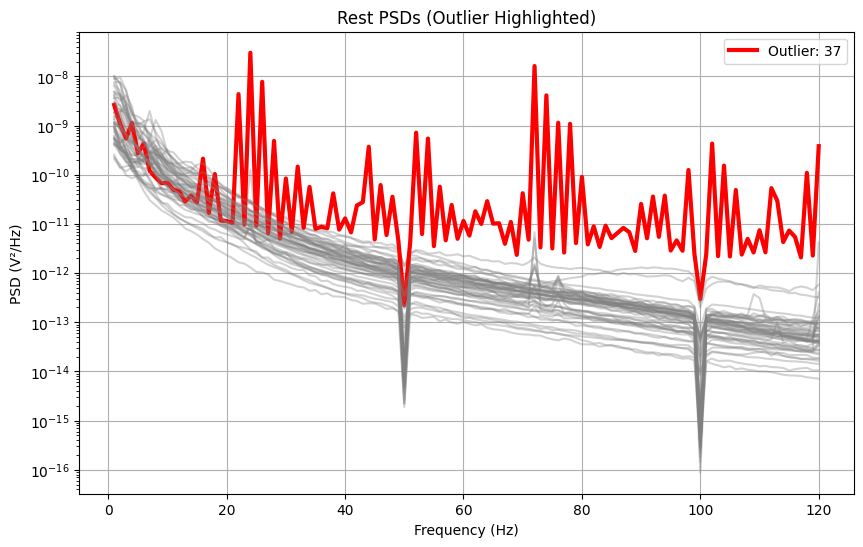

In [ ]:
#new plot

import matplotlib.pyplot as plt

# Subject with highest mean Rest PSD
outlier_subject = subjects[np.argmax(mean_rest_power)]    #.argmax tells which subject has the largest average high-frequency power (sub 37)

# replot the psd with subject 37 as red 

plt.figure(figsize=(10,6))

for subject in sorted(subject_psd_interp.keys()):

    psd = subject_psd_interp[subject]["rest"]["psd"]

    if subject == outlier_subject:

        plt.plot(
            common_freqs,
            psd,
            color="red",
            linewidth=3,
            label=f"Outlier: {subject}"
        )

    else:

        plt.plot(
            common_freqs,
            psd,
            color="gray",
            alpha=0.35
        )

plt.yscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (V²/Hz)")
plt.title("Rest PSDs (Outlier Highlighted)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# We have not proven that Subject 37 is "bad."

# We have only shown that

# Subject 37 has much larger average high-frequency power during rest than the other subjects.

In [ ]:
# now in the below code, we are checking if subject 37 has outliers in speech and music also

In [63]:
import numpy as np
from scipy.stats import zscore

# Frequency range to analyze
mask = (common_freqs >= 20) & (common_freqs <= 120)

conditions = ["speech", "music", "rest"]

for condition in conditions:

    print("=" * 50)
    print(f"{condition.upper()}")

    subjects = []
    mean_power = []

    for subject in sorted(subject_psd_interp.keys()):

        psd = subject_psd_interp[subject][condition]["psd"]

        subjects.append(subject)
        mean_power.append(np.mean(psd[mask]))

    mean_power = np.array(mean_power)

    z = zscore(mean_power)

    found = False

    for subj, score, power in zip(subjects, z, mean_power):
        if abs(score) > 3:
            found = True
            print(f"Outlier -> Subject {subj}: z = {score:.2f}, mean PSD = {power:.3e}")

    if not found:
        print("No subjects exceeded the outlier threshold (|z| > 3)")

SPEECH
No subjects exceeded the outlier threshold (|z| > 3)
MUSIC
No subjects exceeded the outlier threshold (|z| > 3)
REST
Outlier -> Subject 37: z = 7.00, mean PSD = 6.881e-10


In [ ]:
# Now we will check which channels contribute to sub 37 behaving as outlier 

In [48]:
print(subject_psd_interp["37"]["rest"]["psd"].shape)

(120,)


In [49]:
print(subject_psd["37"]["rest"]["psd"].shape)

(6, 82, 477)


In [53]:
import numpy as np
import matplotlib.pyplot as plt

subject = "37"

psd = subject_psd[subject]["rest"]["psd"]      # (6,82,477)
freqs = subject_psd[subject]["rest"]["freqs"]

# Average across epochs ONLY
channel_psd = psd.mean(axis=0)                 # (82,477)

print(channel_psd.shape)

(82, 477)


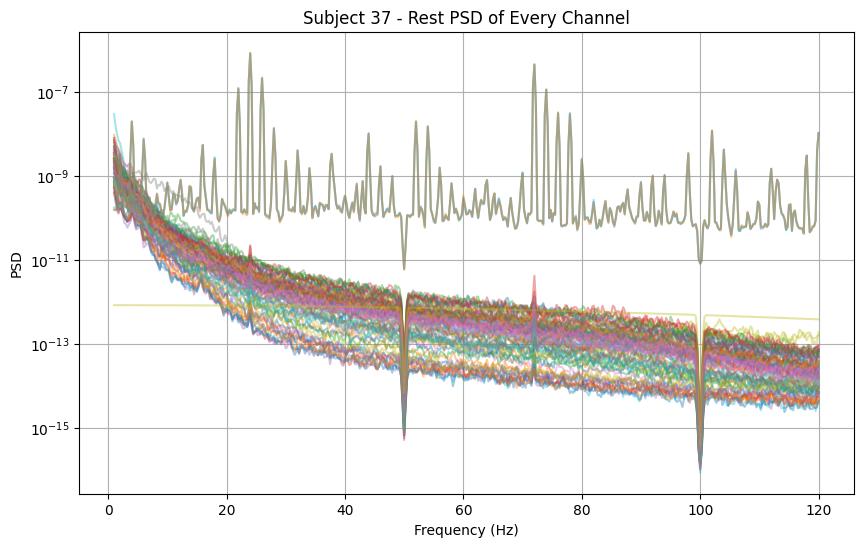

In [54]:
plt.figure(figsize=(10,6))

for ch in range(channel_psd.shape[0]):
    plt.semilogy(freqs, channel_psd[ch], alpha=0.4)

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Subject 37 - Rest PSD of Every Channel")
plt.grid(True)

plt.show()

In [ ]:
# these colors represent 82 different channels 

# It appears that one channel (or possibly a very small number of channels) is responsible for the abnormal PSD. 

In [55]:
mask = (freqs >= 20) & (freqs <= 120)

mean_power = channel_psd[:, mask].mean(axis=1)

order = np.argsort(mean_power)[::-1]

print("Channels ranked by average power:\n")

for idx in order[:10]:
    print(f"{idx:3d}  {mean_power[idx]:.3e}")

Channels ranked by average power:

 81  6.641e-09
 79  6.629e-09
 80  6.537e-09
 72  2.020e-12
  7  1.836e-12
 33  1.702e-12
 15  1.699e-12
 73  1.629e-12
 62  1.626e-12
 32  1.595e-12


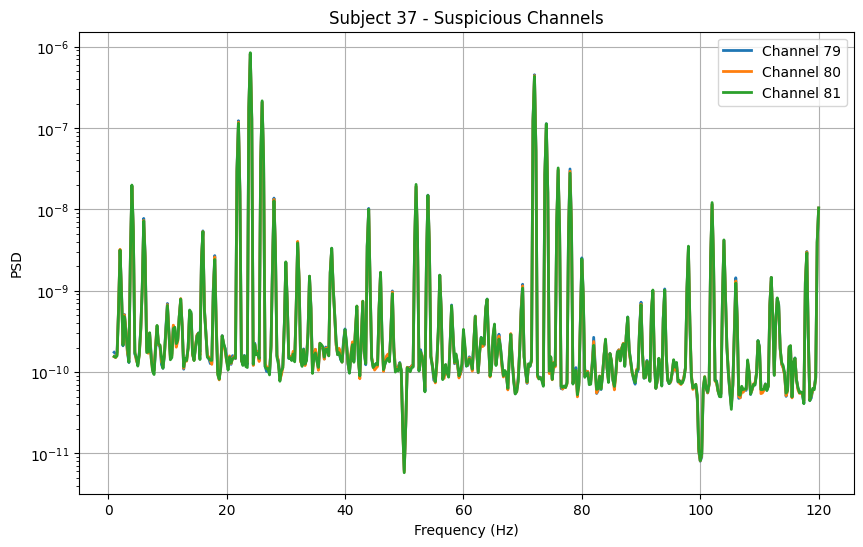

In [56]:
plt.figure(figsize=(10,6))

# Plot only the three suspicious channels
for ch in [79, 80, 81]:
    plt.semilogy(freqs, channel_psd[ch], linewidth=2, label=f"Channel {ch}")

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Subject 37 - Suspicious Channels")
plt.legend()
plt.grid(True)
plt.show()

In [61]:
for i, ch in enumerate(preprocessed_rest["37"].ch_names):
    print(i, ch)

0 C01
1 C02
2 C03
3 C04
4 C05
5 C06
6 C07
7 C09
8 C10
9 C11
10 C12
11 C13
12 C14
13 C15
14 C16
15 C17
16 C18
17 C19
18 C20
19 C21
20 C22
21 C23
22 C24
23 C25
24 C26
25 C27
26 C28
27 C29
28 C30
29 C31
30 C32
31 C33
32 C34
33 C35
34 C36
35 C37
36 C38
37 C39
38 C40
39 C41
40 C42
41 C43
42 C44
43 C45
44 C46
45 C47
46 C48
47 F49
48 F50
49 F51
50 F52
51 F53
52 F54
53 F55
54 F56
55 F57
56 F58
57 F59
58 F60
59 F61
60 F62
61 F63
62 F64
63 hC1
64 hC2
65 hC3
66 hC4
67 hC5
68 hC6
69 hC7
70 hF1
71 hF2
72 hF3
73 hF4
74 hF5
75 hF6
76 hF7
77 hF8
78 DL1
79 DL2
80 DL3
81 DL4


In [62]:
print(preprocessed_rest["37"].info["bads"])

[]


In [51]:
# OVERALL PIPELINE

# Raw BrainVision (.vhdr)

#         ↓

# Preprocessing notebook
#     • remove bad channels
#     • notch filter
#     • CAR
#     • save .fif

#         ↓

# Load preprocessed .fif

#         ↓

# Read events.tsv

#         ↓

# Create speech/music epochs

#         ↓

# Create rest segments

#         ↓

# Compute Welch PSD

#         ↓

# Average epochs

#         ↓

# Average channels

#         ↓

# Interpolate to common frequency grid

#         ↓

# Average subjects

#         ↓

# SEM

#         ↓

# Plot

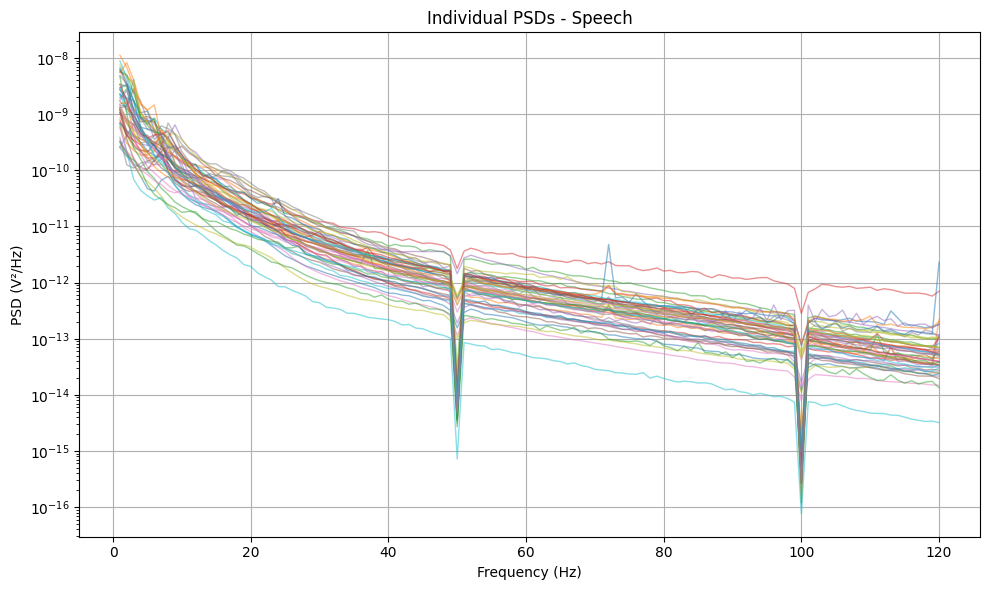

In [52]:
# Individual Speech PSDs

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for subject in sorted(subject_psd_interp.keys()):
    plt.plot(
        subject_psd_interp[subject]["speech"]["freqs"],
        subject_psd_interp[subject]["speech"]["psd"],
        alpha=0.5,
        linewidth=1
    )

plt.yscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (V²/Hz)")
plt.title("Individual PSDs - Speech")
plt.grid(True)
plt.tight_layout()
plt.show()

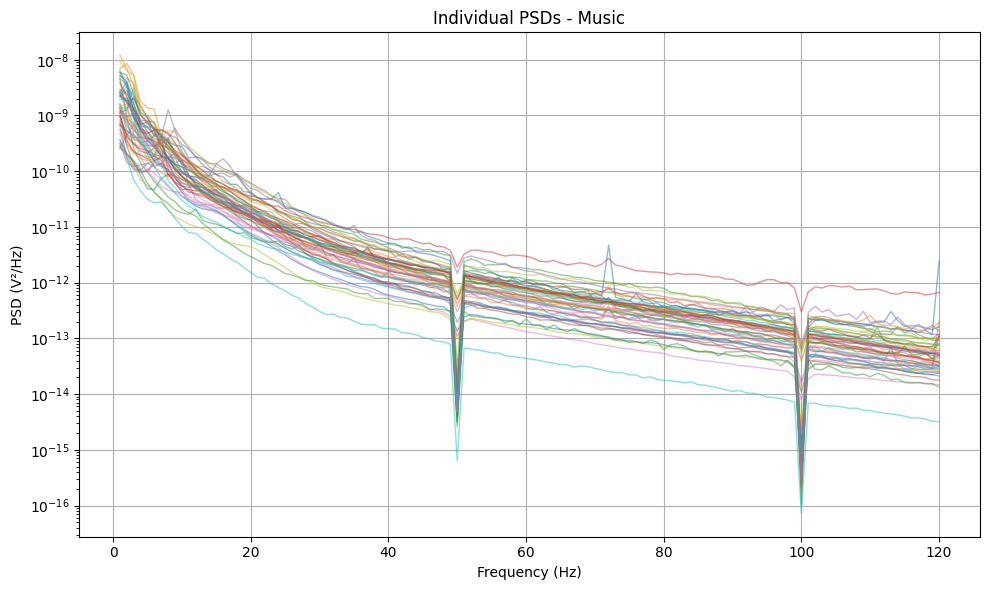

In [53]:
# Individual Music PSDs

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for subject in sorted(subject_psd_interp.keys()):
    plt.plot(
        subject_psd_interp[subject]["music"]["freqs"],
        subject_psd_interp[subject]["music"]["psd"],
        alpha=0.5,
        linewidth=1
    )

plt.yscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (V²/Hz)")
plt.title("Individual PSDs - Music")
plt.grid(True)
plt.tight_layout()
plt.show()

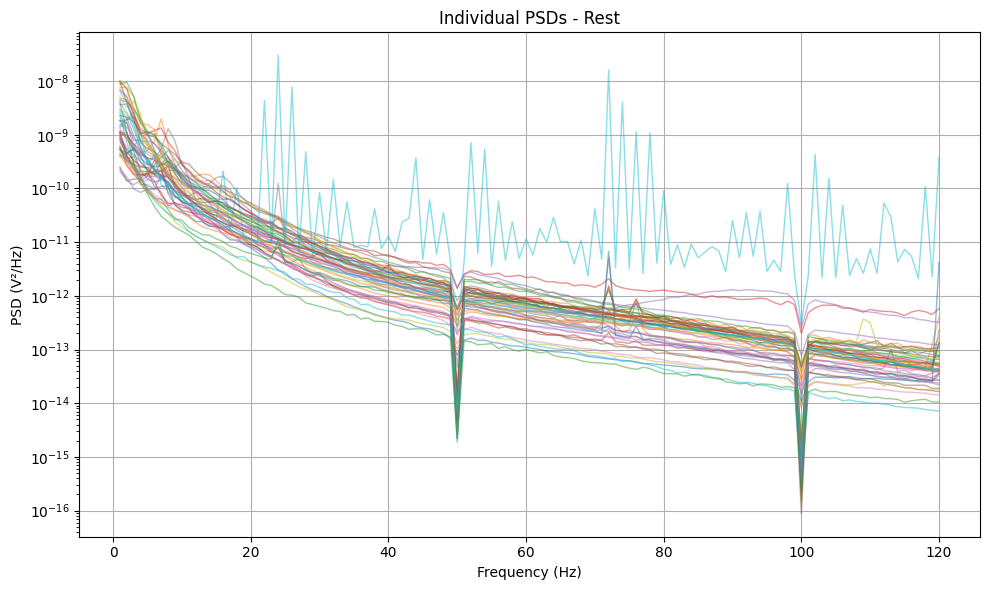

In [54]:
# Individual Rest PSDs

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for subject in sorted(subject_psd_interp.keys()):
    plt.plot(
        subject_psd_interp[subject]["rest"]["freqs"],
        subject_psd_interp[subject]["rest"]["psd"],
        alpha=0.5,
        linewidth=1
    )

plt.yscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (V²/Hz)")
plt.title("Individual PSDs - Rest")
plt.grid(True)
plt.tight_layout()
plt.show()

In [64]:
# STATISTICAL ANALYSIS

In [67]:
print(band_power_df.groupby("Condition").size())

print("\nNumber of unique subjects:",
      band_power_df["Subject"].nunique())

Condition
music     50
rest      50
speech    50
dtype: int64

Number of unique subjects: 50


In [68]:
!pip install pingouin

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tabulate-0.10.0-py3-none-any.whl.metadata (40 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\muqadasah\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [70]:
import sys
!{sys.executable} -m pip install pingouin


[notice] A new release of pip is available: 24.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



  Using cached pingouin-0.6.1-py3-none-any.whl.metadata (19 kB)
  Using cached pandas_flavor-0.8.1-py3-none-any.whl.metadata (6.6 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached pingouin-0.6.1-py3-none-any.whl (203 kB)
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB 

In [ ]:
# The hypotheses are:

# H₀ (Null hypothesis): The mean log PSD at all frequencies is same during Speech, Music, and Rest.
# H₁ (Alternative hypothesis): Not all means are equal

# ANOVA will test this single hypothesis

In [79]:
# Create a log-transformed dataframe

import numpy as np

band_power_log_df = band_power_df.copy()

bands = ["Delta", "Theta", "Alpha", "Beta", "HFB"]

for band in bands:
    band_power_log_df[band] = np.log10(band_power_log_df[band])

In [ ]:
# raw signal
#         ↓
# PSD
#         ↓
# average power
#         ↓
# ANOVA

In [83]:
#new statistical test

import numpy as np
import pandas as pd

rows = []

for subject in sorted(subject_psd_interp.keys()):

    for condition in ["speech", "music", "rest"]:

        psd = subject_psd_interp[subject][condition]["psd"]

        for f, power in zip(common_freqs, psd):

            rows.append({
                "Subject": subject,
                "Condition": condition,
                "Frequency": f,
                "PSD": power
            })

freq_df = pd.DataFrame(rows)

freq_df.head()

,Subject,Condition,Frequency,PSD
0,01,speech,1,2.552081e-10
1,01,speech,2,1.779008e-10
2,01,speech,3,1.282470e-10
3,01,speech,4,7.870000e-11
4,01,speech,5,4.673621e-11


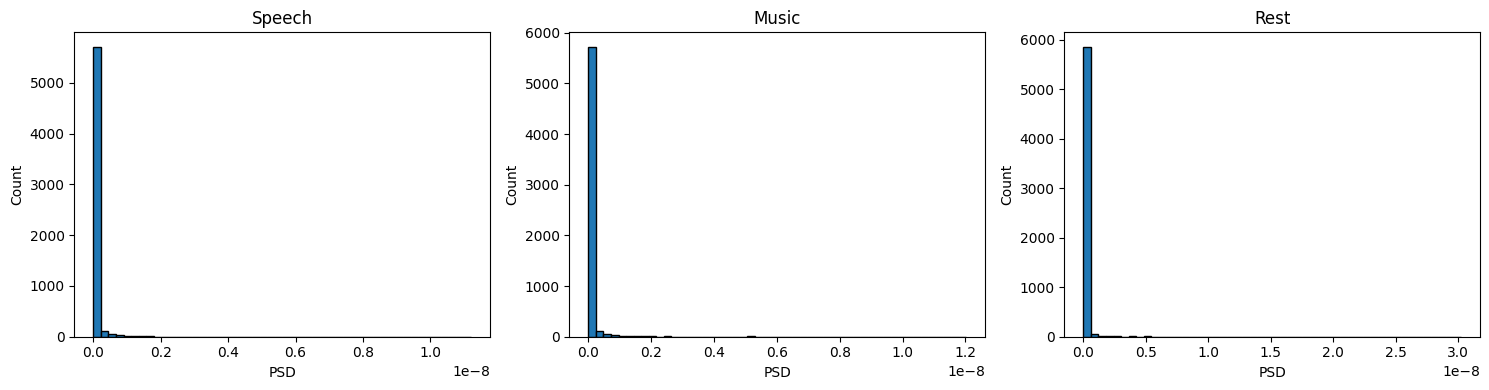

In [92]:
import matplotlib.pyplot as plt

conditions = ["speech", "music", "rest"]

plt.figure(figsize=(15,4))

for i, condition in enumerate(conditions):

    plt.subplot(1,3,i+1)

    data = freq_df.loc[
        freq_df["Condition"] == condition,
        "PSD"
    ]

    plt.hist(data, bins=50, edgecolor="black")

    plt.title(condition.capitalize())
    plt.xlabel("PSD")
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [99]:

# this means there are a lot of frequencies who have low psd value

# Count
#  ^
#  |█████████████████████████████████████████
#  |█
#  |█
#  |█
#  |█
#  +-------------------------------------------->
#          PSD

# this is right skewed data 
# Almost all the PSD values are crammed near zero.
# Then there's a very long tail stretching to the right.

# why a lot of low psds?
# Because your PSD curves all look like this:

# PSD
#  ^
#  |\
#  | \
#  |  \
#  |   \
#  |    \
#  +------------------------>
#  1Hz                120Hz



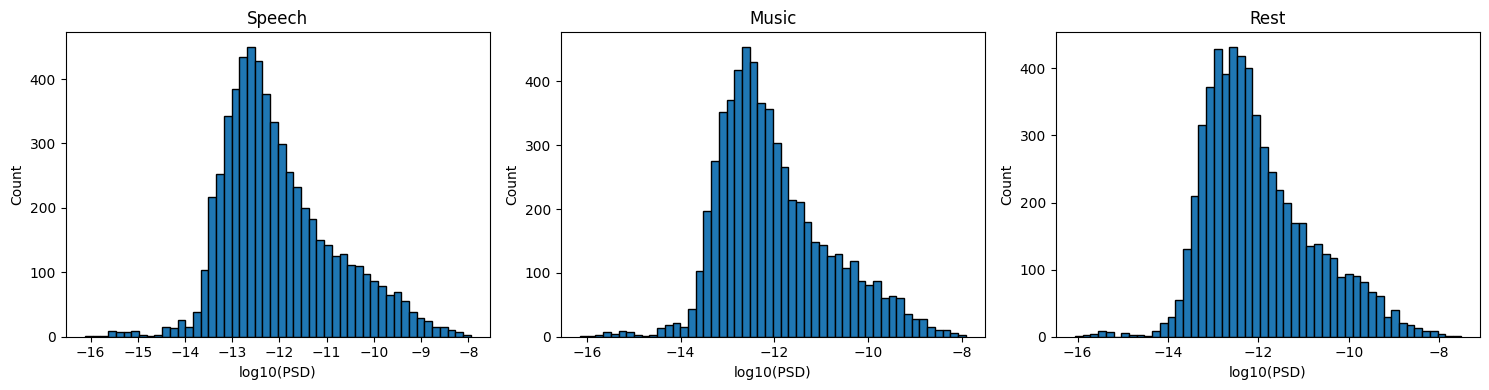

In [100]:
import matplotlib.pyplot as plt

conditions = ["speech", "music", "rest"]

plt.figure(figsize=(15,4))

for i, condition in enumerate(conditions):

    plt.subplot(1,3,i+1)

    data = freq_df.loc[
        freq_df["Condition"] == condition,
        "logPSD"
    ]

    plt.hist(data, bins=50, edgecolor="black")

    plt.title(condition.capitalize())
    plt.xlabel("log10(PSD)")
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [101]:
from scipy.stats import skew

for condition in ["speech", "music", "rest"]:

    original = freq_df.loc[
        freq_df["Condition"] == condition,
        "PSD"
    ]

    transformed = freq_df.loc[
        freq_df["Condition"] == condition,
        "logPSD"
    ]

    print(f"\n{condition.upper()}")
    print(f"Original skewness : {skew(original):.2f}")
    print(f"Log PSD skewness  : {skew(transformed):.2f}")


SPEECH
Original skewness : 13.41
Log PSD skewness  : 0.67

MUSIC
Original skewness : 13.75
Log PSD skewness  : 0.67

REST
Original skewness : 23.91
Log PSD skewness  : 0.70


In [ ]:
# "The first histogram showed that the original PSD values were highly right-skewed. 
# Since repeated-measures ANOVA assumes approximately normal data, 
# I applied a log transformation to reduce the skewness.
# I then plotted the histogram again to verify that the transformed data had a more symmetric distribution 
# before performing the statistical analysis."

In [102]:
import numpy as np

freq_df["logPSD"] = np.log10(freq_df["PSD"])

In [103]:
import pingouin as pg
import pandas as pd

results = []

for freq in sorted(freq_df["Frequency"].unique()):

    data = freq_df[freq_df["Frequency"] == freq]

    aov = pg.rm_anova(
        data=data,
        dv="logPSD",
        within="Condition",
        subject="Subject",
        detailed=True
    )

    results.append({
        "Frequency": freq,
        "F": aov.loc[0, "F"],
        "p": aov.loc[0, "p_GG_corr"],      # Greenhouse-Geisser corrected p
        "eta2": aov.loc[0, "ng2"]
    })

anova_freq = pd.DataFrame(results)

anova_freq.head()

,Frequency,F,p,eta2
0,1,0.090223,0.780253,0.000218
1,2,0.020701,0.896868,0.000062
2,3,0.197772,0.679666,0.000550
3,4,1.032070,0.322138,0.002761
4,5,0.456007,0.522805,0.001094


In [109]:
# significant = anova_freq[anova_freq["p"] < 0.05]

alpha = 0.05
significant = anova_freq[anova_freq["p"] < alpha]
print(significant)

# i.e. Show me all the frequencies where the p-value is smaller than my chosen significance level (α = 0.05)

    Frequency         F         p      eta2     p_fdr  Significant
49         50  6.954058  0.011018  0.017771  0.661095        False
99        100  6.984571  0.010751  0.021309  0.661095        False


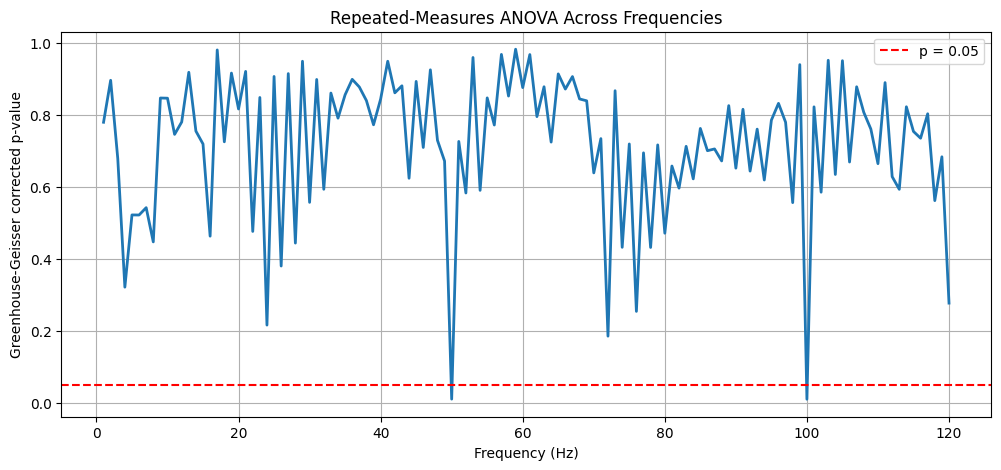

In [105]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    anova_freq["Frequency"],
    anova_freq["p"],
    linewidth=2
)

plt.axhline(
    0.05,
    color="red",
    linestyle="--",
    label="p = 0.05"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Greenhouse-Geisser corrected p-value")
plt.title("Repeated-Measures ANOVA Across Frequencies")

plt.legend()
plt.grid(True)

plt.show()

In [1]:
#FDR (false discovery rate)
from statsmodels.stats.multitest import multipletests

reject, p_fdr, _, _ = multipletests(
    anova_freq["p"],
    alpha=0.05,
    method="fdr_bh"
)

anova_freq["p_fdr"] = p_fdr
anova_freq["Significant"] = reject

anova_freq[anova_freq["Significant"]]

NameError: name 'anova_freq' is not defined

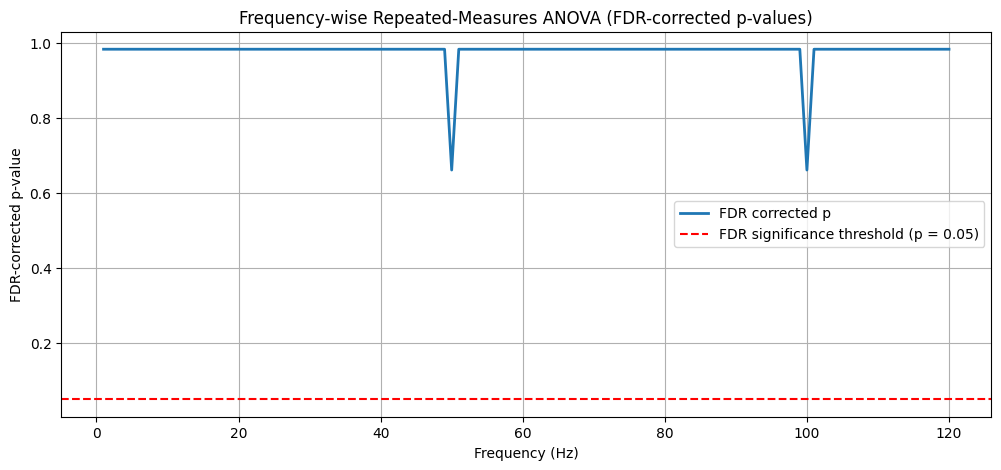

In [91]:
plt.figure(figsize=(12,5))

plt.plot(
    anova_freq["Frequency"],
    anova_freq["p_fdr"],
    linewidth=2,
    label="FDR corrected p"
)

plt.axhline(
    0.05,
    color="red",
    linestyle="--",
    # label="Significance threshold"
    label="FDR significance threshold (p = 0.05)"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("FDR-corrected p-value")
# plt.title("Frequency-wise Repeated-Measures ANOVA (FDR Corrected)")
plt.title("Frequency-wise Repeated-Measures ANOVA (FDR-corrected p-values)")

plt.grid(True)
plt.legend()

plt.show()

In [ ]:
# After applying the False Discovery Rate (FDR) correction, 
# no frequencies had corrected p-values below 0.05. 
# Therefore, we failed to reject the null hypothesis at all analyzed frequencies. 
# This indicates that we did not find statistically significant evidence that the mean logPSD differed among the Speech, Music, 
# and Rest conditions at any frequency.

In [ ]:
# All corrected p-values are close to 1.

# That means the evidence against the null hypothesis is generally very weak across the entire frequency spectrum.

# If there had been a genuine effect, we would expect to see one or more frequencies where the blue curve crossed below the red line.

In [119]:
# import nibabel as nib
# import matplotlib.pyplot as plt

# img = nib.load(r"E:\IEEG-FMRI Dataset\sub-01\ses-mri3t\anat\sub-01_ses-mri3t_run-1_T1w.nii.gz")

# data = img.get_fdata()

# print(data.shape)

In [118]:
# fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# ax[0].imshow(data[200, :, :].T, cmap="gray", origin="lower")
# ax[0].set_title("Sagittal")

# ax[1].imshow(data[:, 200, :].T, cmap="gray", origin="lower")
# ax[1].set_title("Coronal")

# ax[2].imshow(data[:, :, 150].T, cmap="gray", origin="lower")
# ax[2].set_title("Axial")

# for a in ax:
#     a.axis("off")

# plt.show()